# 🧹 **Data Cleaning Tutorial** 🧼

¡Hola! 👋 Bienvenido/a a un nuevo mini curso donde aprenderás a dominar algunos de los aspectos más fundamentales de **Python para ciencia de datos** 🐍📊.  

Si has seguido en orden cada uno de los cursos que tengo disponibles, es muy probable que ya te hayas comenzado a hacer algunas preguntas clave sobre tus bases de datos, como por ejemplo:  

- ¿Qué debería hacer cuando tengo muchos **datos faltantes**? 🤔  
- ¿Qué técnicas puedo implementar para no tener tantos **outliers** que afecten mis resultados finales? ⚠️📉  

¡Pues estás en el lugar correcto! A lo largo de este mini curso, te presentaré una serie de **técnicas sencillas pero poderosas** que te serán de gran ayuda para mejorar la calidad de tus datos y avanzar en tu camino hacia dominar la **ciencia de datos en Python**. 💪🔍

Así que, ¡sin más preámbulos... **comencemos**! 🚀

## 🗂️ **La base de datos**

Para este nuevo viaje lleno de aprendizajes 🚀, utilizaremos la base de datos **New York City Airbnb Open Data**. Si deseas replicar cada uno de los pasos que aquí te propongo, puedes descargarla directamente desde el repositorio 📁. Sin embargo, si ya cuentas con otra base de datos, ¡no te preocupes! Solo debes prestar atención y adaptar cada paso a tus propias necesidades. 👀💡

### 🧭 Un poco de contexto...

Desde 2008, huéspedes y anfitriones han usado la plataforma de **Airbnb** para expandir las posibilidades de viaje, ofreciendo formas mucho más **únicas y personalizadas** de explorar el mundo 🌍. Esta base de datos contiene un registro de propiedades y métricas en la ciudad de **Nueva York durante el año 2009**, lo que nos permitirá hacer análisis muy interesantes.

Este conjunto de datos incluye información clave para explorar el comportamiento de los anfitriones, la disponibilidad geográfica de las propiedades, y diversas métricas que pueden ayudarte a **hacer predicciones y extraer conclusiones relevantes** 📊🧠.

### 📌 Variables disponibles en el dataset

### 🗂️ **Variables del dataset**

1. **`id`**: Número de identificación de la propiedad 🏷️  
2. **`name`**: Nombre de la propiedad 🏡  
3. **`host_id`**: Identificación del anfitrión 🙋‍♂️  
4. **`host_name`**: Nombre del anfitrión 🧑‍💼  
5. **`neighbourhood_group`**: Ubicación general de la propiedad, distribuida principalmente en **Manhattan (44%)** y **Brooklyn (41%)** 🗺️  
6. **`neighbourhood`**: Área específica donde se encuentra la propiedad 📍  
7. **`latitude`**: Coordenada de latitud 🌐  
8. **`longitude`**: Coordenada de longitud 📍  
9. **`room_type`**: Tipo de espacio que ofrece la propiedad (por ejemplo, habitación privada, apartamento completo, etc.) 🛏️  
10. **`price`**: Precio en dólares 💲  
11. **`minimum_nights`**: Cantidad mínima de noches requeridas para reservar la propiedad 💤  
12. **`number_of_reviews`**: Número total de reseñas recibidas por la propiedad 📝  
13. **`last_review`**: Fecha de la última reseña hecha a la propiedad 📆  
14. **`reviews_per_month`**: Promedio de reseñas que recibe la propiedad mensualmente 📊  
15. **`calculated_host_listings_count`**: Número de propiedades que tiene cada anfitrión listadas en la plataforma 🏘️  
16. **`availability_365`**: Número de días al año en los que la propiedad está disponible para reservar 📅  






Ahora sí, una vez hemos comprendido —más o menos— con qué tipo de datos vamos a trabajar, ¡podemos empezar! 🎉

Como siempre, el **primer paso** es importar la base de datos. Para ello, te recomiendo tener el archivo **en la misma carpeta** que tu espacio de trabajo 🗂️. Esto hará que el proceso de importación sea mucho más sencillo y sin dolores de cabeza 😌.

A continuación, te muestro cómo hacerlo:

In [1]:
import pandas as pd
df=pd.read_csv(r".\AB_NYC_2019.csv", delimiter=",", quotechar='"')
print(df)


             id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

           host_name neighbourhood_grou

### 🛠️ Exploración inicial del dataset

Una vez importada nuestra base de datos, realizaremos **tres pasos adicionales** que, si bien no corresponden directamente al proceso de limpieza de datos, nos ayudarán a **comprender mucho mejor el comportamiento de las variables** 📊. Estos pasos son los siguientes:

1. 🔍 **Identificación de valores nulos**: Este paso es crucial para detectar qué columnas presentan datos faltantes. Así, podremos pensar en técnicas de imputación adecuadas y evitar, en la medida de lo posible, eliminar información valiosa.

2. 📈 **Estadísticas descriptivas**:
   - Para las **variables numéricas**, nos enfocaremos en conocer medidas como la media, mediana, desviación estándar, entre otras.
   - Para las **variables categóricas**, analizaremos la frecuencia de aparición de cada categoría para identificar posibles desequilibrios o errores.

3. 📦 **Boxplots para variables numéricas**: Con este tipo de gráfico identificaremos posibles *outliers*, es decir, valores que están fuera del rango típico de los datos. Esto nos permitirá tomar decisiones informadas sobre cómo tratarlos más adelante.


In [2]:
# Antes de continuar es importante importar desde el incio todas las librerías
# que vamos a estar usando a lo largo de la limpieza de la base de datos

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **🔍 Valores nulos**

A continuación, te comparto el código que suelo emplear para identificar valores nulos en un dataset. 🧹💾  
Recuerda que cada uno de estos procedimientos puedes adaptarlo según las necesidades específicas de tu base de datos 📊:

In [3]:
df.isna().sum().reset_index().rename(columns={"index": "Variable", 0: "Valores faltantes"}).assign(**{"Tipo de dato": lambda x: x["Variable"].map(df.dtypes.astype(str))})



,Variable,Valores faltantes,Tipo de dato
0,id,0,int64
1,name,16,object
2,host_id,0,int64
3,host_name,21,object
4,neighbourhood_group,0,object
5,neighbourhood,0,object
6,latitude,0,float64
7,longitude,0,float64
8,room_type,0,object
9,price,0,int64


A partir de este primer ejercicio, podemos evidenciar que existen algunas variables con valores faltantes. En particular, **`name`**, **`host_name`**, **`last_review`** y **`reviews_per_month`** presentan problemas notorios de *missing values*.

Estas serán las variables en las que centraremos nuestra atención cuando abordemos el proceso de **imputación de datos**.  

Pero antes de continuar, probablemente te estés preguntando…  
**¿Qué es la imputación de datos?**  
¡Aquí te lo explico rápidamente antes de seguir! 👇

#### 🧩 ¿Qué es la imputación de datos?

La **imputación** es una técnica común en el procesamiento de datos, especialmente útil cuando trabajamos con información numérica incompleta. Su objetivo principal es **reemplazar los valores faltantes** (NaN) con datos que permitan mantener la coherencia y utilidad del conjunto.

##### ☄️ Imputación de Valores Nulos

Cuando nos enfrentamos a valores nulos, no siempre es recomendable eliminarlos directamente. En lugar de eso, podemos imputarlos, es decir, **sustituir esos valores vacíos por otros más apropiados**, dependiendo del contexto del análisis. Algunas estrategias comunes son:

- 🔹 Rellenar con **medidas de tendencia central**:  
  - Media (promedio)  
  - Mediana  
  - Moda  

- 🔹 Asignar una **etiqueta personalizada** (por ejemplo, "Desconocido" para datos categóricos).  

- 🔹 Aplicar una **imputación basada en outliers**, si queremos mantener cierta lógica con la dispersión de los datos.




#### **Estadísticas descriptivas** 📊

A partir de las **estadísticas descriptivas** podremos identificar información importante para nuestro análisis futuro, como las **medidas de tendencia central**, en caso de que no deseemos imputar con outliers o valores nulos (`NaN`). 🧠📌


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


Debido a que el propósito de este curso no es realizar un **Análisis Exploratorio de Datos (EDA)** completo, no estaremos profundizando en los resultados obtenidos. Sin embargo, es importante que los tengamos presentes, ya que serán de gran ayuda más adelante. 🧩📁

Así mismo, realizaremos un **análisis breve de las variables categóricas**, enfocado en los siguientes aspectos:  
- **Frecuencia** 📊  
- **Moda** 🎯  
- **Valores únicos** 🔢 
- **Entre otros**

In [5]:
df.describe(include=object)

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


Al igual que con las variables numéricas, en este caso no nos detendremos a analizar de manera detenida los resultados obtenidos. Sin embargo, puede que sean tenidos en cuenta más adelante en caso de requerirse imputación de carácter categórico 🧠.


#### **Box Plot 📦**

En caso de que no los conozcas, los **box plots** son gráficos súper valiosos que nos permiten visualizar el extremo superior, el extremo inferior, los **outliers** (valores por fuera de los extremos), el cuartil superior, la mediana y el cuartil inferior. 📈  

En esta ocasión, solo nos estaremos concentrando en la identificación de **valores atípicos** para su posterior revisión, más no entraremos en detalle sobre los cuartiles o la mediana (los cuales ya pudimos observar durante las estadísticas descriptivas). 😉

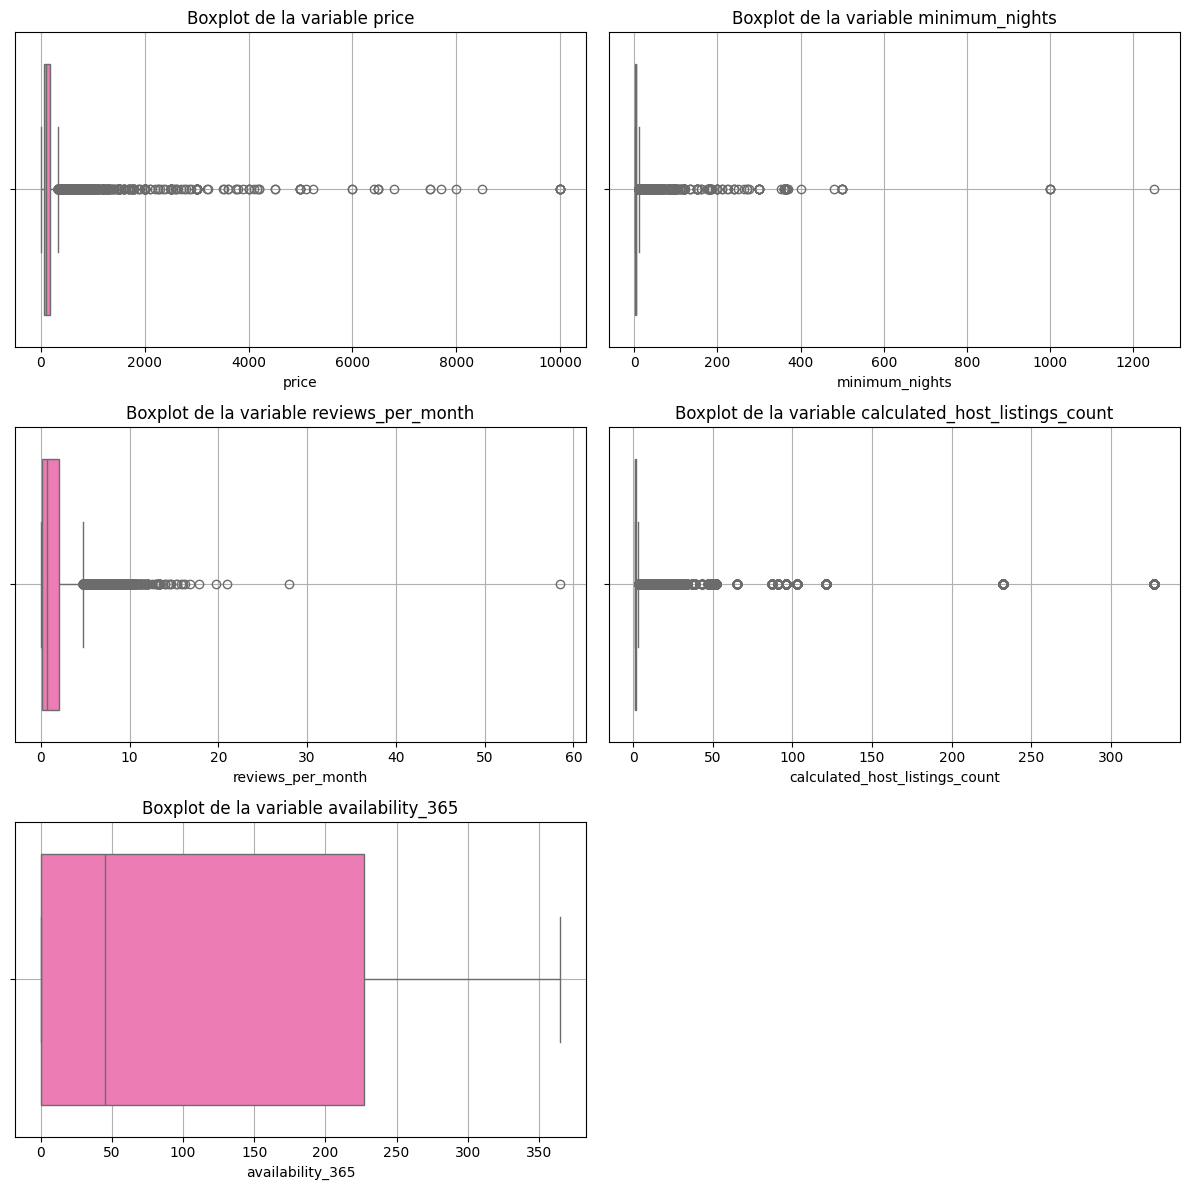

In [6]:
variables = [ 'price', 'minimum_nights',
             'reviews_per_month', 'calculated_host_listings_count','availability_365']  # Asegúrate de que existan en tu DataFrame


n_cols = 2
n_rows = 3

# Crear figura y ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

# Graficar cada variable
for i, var in enumerate(variables):
    sns.boxplot(x=df[var], ax=axes[i], color='hotpink')
    axes[i].set_title(f'Boxplot de la variable {var}')
    axes[i].set_xlabel(var)
    axes[i].grid(True)

# Si sobran subplots (cuando no son múltiplos exactos), los ocultamos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar espaciado
plt.tight_layout()
plt.show()

Como puedes observar, la gran mayoría de las variables numéricas cuentan con valores **outliers** 🚀. En algunos casos, esto tiene sentido, pues, por ejemplo, en el caso de los **precios** en la plataforma de Airbnb es posible encontrar propiedades de todos los rangos que se ajustan a las diferentes necesidades de los huéspedes 🏡.  

También, la **cantidad de reviews por mes** puede variar significativamente dependiendo de la época del año o del nivel de satisfacción que presenten los diferentes huéspedes ✨.  

Sin embargo, hay casos como **minimum_nights** que sí llaman considerablemente la atención, ya que presentan valores bastante elevados ⚠️.  

Para corregir esta estructura de datos, te invito a que continúes en este curso 📚, ya que más adelante te estaré explicando cómo hacerlo paso a paso. 🚀


### **Inicio oficial de la limpieza de datos 🚀**

Para darte una idea más clara de los pasos que estaremos siguiendo, aquí te dejo el listado de cada uno de los procesos que estaré haciendo, en el orden respectivo de ejecución:

1. ✍️ Estaremos cambiándole el nombre a algunas de las columnas, ya que son demasiado largas y llegan a ensuciar un poco la estética del código.
2. 🧹 Daremos manejo a las columnas que tienen valores faltantes.
3. 📈 Daremos manejo a algunos outliers que se pudieron identificar en el boxplot.
4. 🔍 Haremos un enriquecimiento de los datos.

**¡Nota aclaratoria! ⚡:**  
Muchas de las transformaciones que aquí se estarán realizando podrían interpretarse como incongruentes, o que simplemente no van acorde. Esto no es casual, sino que, por el contrario, hace parte del propósito que tengo de enseñarte cómo aplicar técnicas de limpieza de datos 🛠️ para que, cuando las necesites, conozcas su paso a paso y explicación.



#### **Cambio del nombre de variables ✏️**

Esta técnica suele emplearse por dos motivos principales:

1. 📏 En primer lugar, puede que consideres que los nombres iniciales sean demasiado largos, lo que termina por complejizar tu código de manera completamente innecesaria. En ese caso, puedes optar por nombres más cortos sin perder la esencia de lo que quiere transmitir la variable.

2. 🧠 En segundo lugar, puede que sientas que el nombre de tu variable es muy poco diciente, por lo que podrías elegir cambiarlo por uno que transmita de manera breve y concisa la información que esta alberga.


In [7]:
# En caso de que en algún momento queramos retomar la base de datos
# original, crearemos una copia del dataset

df_clean=df.copy() 

In [8]:
df_clean=df_clean.rename(columns={"neighbourhood_group":"neigh._group","calculated_host_listings_count":"host_listings_count"})
df_clean.head()

,id,name,host_id,host_name,neigh._group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


#### **Imputación de valores faltantes 🔍**

Como te diste cuenta, en este dataset tenemos 4 variables con valores faltantes: **`name`**, **`host_name`**, **`last_review`** y **`reviews_per_month`**.  

En muchos casos, podrían sugerirte que para las dos últimas variables lo más adecuado sería eliminar las columnas, ya que presentan una cantidad significativa de valores faltantes. Sin embargo, en este caso, las dejaremos con el objetivo de mostrarte diferentes tipos de imputación y que puedas aprender a aplicarlas según el contexto. 🚀


In [9]:
# Para la primera variable emplearemos las "estadísticas descriptivas" de las variable categóricas
# allí encontramos cual es el nombre más frecuente

df_clean["name"]=df_clean["name"].fillna("Hillside Hotel").astype(str)

In [10]:
# Para el host_name podríamos emplear la misma técnica de llenar los valores faltantes con
# el valor que tenga mayor frecuencia, no obsante, en este caso vamos a usar un valor personalizado

df_clean["host_name"]=df_clean["host_name"].fillna("No registered").astype(str)

In [11]:
# En el caso de last review, podemos imputarlo de dos posibles maneras, en primer lugar puedes ponerle
# la fecha con mayor frecuencia, o poner una fecha "outlier", aqui te dejo ambas alternativas

# df_clean["last_review"]=df_clean["last_review"].fillna("0000-00-00").astype(str)
df_clean["last_review"]=df_clean["last_review"].fillna("2019-06-23").astype(str)


In [12]:
# Finalmente, en el caso de reviews per month podemos hacer algo similar al caso anterior, podemos
# imputarlo con alguna de sus medidas de tendicia central (media, moda, o mediana) o llenarlo con un
# outlier

# df_clean["reviews_per_month"]=df_clean["reviews_per_month"].fillna(1.373221).astype(float)
df_clean["reviews_per_month"]=df_clean["reviews_per_month"].fillna(-1).astype(int)

Una vez hemos organizado estos datos 📊, vamos a poner nuestra atención en las variables que cuentan con **outliers** 🚀.  

Como te conté previamente cuando analizábamos el **boxplot**, hay variables que presentan valores muy fuera de rango, pero que no resultan extraños, ya que la naturaleza de esas variables así lo permite 🌎. Sin embargo, también encontramos otras variables que definitivamente necesitan un tratamiento especial ⚠️.  

No obstante, como mi propósito es mostrarte diferentes herramientas a las que puedes recurrir en estos casos 🛠️, vamos a estar modificando **todas** las variables con outliers, sean o no coherentes, para que conozcas las distintas estrategias que puedes aplicar.

**Nuevamente te recuerdo** ⚠️ puede que algunas de las transformaciones que aquí te presento no te parezcan 100% coherentes, pues como te he mencionado previamente, el propósito de este ejercicio es mostrarte diferentes alternativas y tu dependiendo de tus necesidades (o del dataset), lo ajustes.

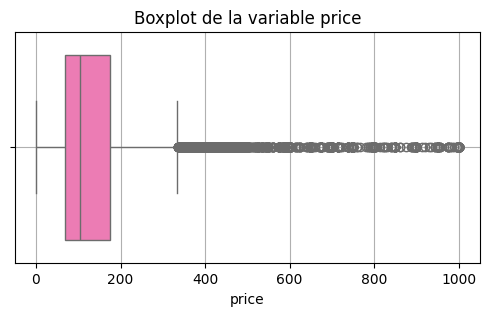

In [13]:
# Dado que price es una de las variables que mayores outliers presenta, te sugiero que filtremos el dataset
df_clean = (
    df_clean
    .query("price <= 1_000")
)

plt.figure(figsize=(6, 3))
sns.boxplot(x=df_clean['price'],color="hotpink")
plt.title('Boxplot de la variable price')
plt.xlabel('price')
plt.grid(True)
plt.show()

Si bien, el gráfico nos sigue mostrando como si tuvieramos un montón de outliers, la verdad es que estamos limitando la influecia de las propiedades cuyo precio son mucho más elevado, lo que facilita mucho más el análisi.

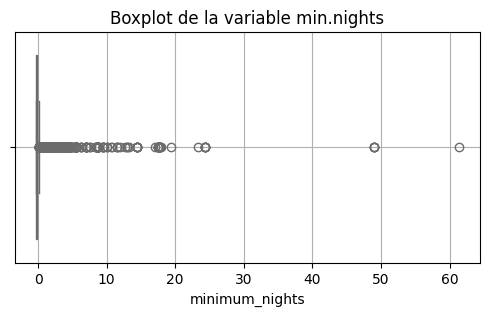

-2.1320955158865223e-17
1.00001027638333


In [14]:
# En el caso de minimum_nights te propongo que apliquemos una técnica de estandarización, la cual 
# asegura que nuestros datos tengan una media de 0 y varianza 1. Para ello tendremos que importar una
# librerí con la que no hemos trabajo antes, pero que es super útil para temas de machine learnin, si deseas
# indagar más sobre ella te invito a que revises mis cursos de pipelines y aprendizaje supervidado.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_clean['minimum_nights'] = scaler.fit_transform(df_clean[['minimum_nights']])

plt.figure(figsize=(6, 3))
sns.boxplot(x=df_clean['minimum_nights'],color="hotpink")
plt.title('Boxplot de la variable min.nights')
plt.xlabel('minimum_nights')
plt.grid(True)
plt.show()

print(df_clean['minimum_nights'].mean()) 
print(df_clean['minimum_nights'].std())


Al igual que en el caso anterior, por medio del boxplot pareciera que continuamos teniendo outliers, pero la verdad es que ahora nuestros datos son mucho más manejables pues cuentan con una media muy cercana a cero y una varianza de 1.

In [15]:
# Repetimos el proceso de estandarizaión para la vaiable reviews_per_month

scaler = StandardScaler()
df_clean['reviews_per_month'] = scaler.fit_transform(df_clean[['reviews_per_month']])

print(df_clean['reviews_per_month'].mean())  # cercano a 0
print(df_clean['reviews_per_month'].std())

-3.738468849773628e-17
1.0000102763833298


In [16]:
# Para cocluir, vamos a normalizar la variable de host_listings

from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_clean['host_listings_count'] = minmax_scaler.fit_transform(df_clean[['host_listings_count']])

print(df_clean['host_listings_count'].min())  
print(df_clean['host_listings_count'].max())

0.0
1.0


Pobablemente, esta última transformación es la que menos te puede hacer sentido, sin embargo, tomala únicamente como un ejemplo de como puedes aplicar la normalización de variables

#### **Enriquecimiento de los datos ✨**

El enriquecimiento de los datos se suele emplear como una técnica para añadir más columnas a nuestro dataset 📊 que aporten información valiosa a la que ya tenemos disponible. Esto, como su nombre lo indica, nos permitirá enriquecer nuestro análisis 🔍.  
Aquí te propongo algunas posibles alternativas:



In [17]:
df_clean['revenues'] = df_clean['price'] * df_clean['availability_365']

A partir de esta última línea de código podríamos emprender todo un nuevo análisis enfocado en las ganancias que generan las diferentes propiedades listadas en Airbnb 💰.  
Recuerda: todas las técnicas de enriquecimiento deben ir en función del propósito que te hayas trazado al inicio 🎯.


In [18]:
df_clean['expected_daily_revenue'] = df_clean['revenues'] / 365

Con esta nueva columna podemos analizar el ingreso promedio esperado por día 📈, distribuyendo los ingresos anuales de disponibilidad en todo el año.  
Esto es bastante útil, pues ofrece una métrica estandarizada para comparar propiedades 🏡, sin importar si tienen más o menos días disponibles.  
Además, facilita el análisis entre propiedades, ya que ya no hablamos en términos de ganancias anuales sino diarias 📅.  
Y si tu propósito es mucho más complejo, esta métrica también puede ser de gran ayuda para implementar técnicas de clustering, segmentación de propietarios, entre otros 🤓.


### 🧼 Conclusión del curso de limpieza de datos

Para concluir este curso de limpieza de datos, veamos cómo ha quedado nuestra base de datos después de haberle aplicado todas las técnicas de limpieza que te acabo de enseñar 🛠️:

In [21]:
df_clean.head()

,id,name,host_id,host_name,neigh._group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,host_listings_count,availability_365,revenues,expected_daily_revenue
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,-0.294766,9,2018-10-19,-0.364574,0.015337,365,54385,149.000000
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,-0.294766,45,2019-05-21,-0.364574,0.003067,355,79875,218.835616
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,-0.196075,0,2019-06-23,-0.966745,0.000000,365,54750,150.000000
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,-0.294766,270,2019-07-05,2.044106,0.000000,194,17266,47.304110
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,0.149341,9,2018-11-19,-0.364574,0.000000,0,0,0.000000


In [22]:
df_clean.isna().sum().reset_index().rename(columns={"index": "Variable", 0: "Valores faltantes"})

,Variable,Valores faltantes
0,id,0
1,name,0
2,host_id,0
3,host_name,0
4,neigh._group,0
5,neighbourhood,0
6,latitude,0
7,longitude,0
8,room_type,0
9,price,0


Una vez hemos impreso nuestra base de datos, podemos ver claramente cómo ha **cambiado significativamente** gracias a todas las transformaciones realizadas 🧼📊.  

Ahora contamos con una estructura **mucho más clara, ordenada y coherente**, lo que hace que los datos sean **más manejables**, legibles y listos para el análisis 🧠💡.  

Este proceso de limpieza no solo mejora la calidad del dataset, sino que también **facilita enormemente la extracción de insights** relevantes, mejora la interpretación y allana el camino para aplicar técnicas más avanzadas como modelado, segmentación o visualización 📈🚀.

¡Felicidades por llegar hasta aquí! 🎉  
No olvides seguir aprendiendo y poner en práctica todo lo que has aprendido 🚀